# Homework 3

## Essential Information

* Deadline: Monday Apr 14th (11:59 PM)
* Independent Assignment: This assignment should be done independently
    * Sharing of solutions is not allowed
    * Sharing of solution _values_ to help check your work is allowed and encouraged.
    * Discussing _approaches_ is discouraged. If this occurs please cite who you discussed with. I want you thinking through how to solve this problem on your own.
    * Collaborative support with the practicalities of coding (I.E. helping someone with pandas or the google colab environment) is encouraged and fine. Likewise, so is higher level discussion simimlar to what we've seen in past assignments.

## Overview

The purpose of this assignment is a bit split:

* Implement a gradient descent algorithm
* Implement some core metrics

This is to set up for:

* Perform a large, and realistic offline evaluation
* Make specific product decisions based on the offline evaluation
* Perform an algorithm tuing and reflect on how well it worked.

This should prepare you for a broad range of algorithm tasks you might need to do in the future.

## Outline

I've broken down this assignment into 5 core parts:

* (0 points) Step 1 - Setup
* (15 points) Step 2 - Building an SVD algorithm
* (25 points) Step 3 - Building Metrics
* (45 points) Step 4 - big evaluation
* (15 points) Step 5 - Parameter Tuning

Most of these will call for you to implement a basic algorithm of computation, and then produce a practical result from it (often a top-10 movie list). Some questions will then ask you to follow-up with some practical evaluation in a series of short-answer questions.

## Notes:
 * All instructions are in-line in this document. We've tried to balance clarity with brevity here, which means that there might be a few instructions that we're _assuming_ are clear enough. If you're ever unclear what is expected or required of you please reach out over slack or email for clarification.
 * As _this_ document will be hard to meaningfully update after the assignment begins, make sure you regularly check canvas and slack for any updates, new hints or FAQs
 * While you are not required to use the pandas framework for doing this data analysis, it's commonly considered a power-tool for this sort of work, and you might find many parts of this assignment much easier _with_ pandas than without. I'm hoping to provide some pandas hints in lecture, and on slack, but I'm not an expert either. You are encouraged to read about pandas, and it's entirely reasonable to google around for how to perform some of these basic operations.

# How to get started and what to submit

To start this assignment, make a copy of this notebook: <https://colab.research.google.com/drive/1gGUc1JFsrJokG07dZIG-qoR9Oaf4TopJ?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

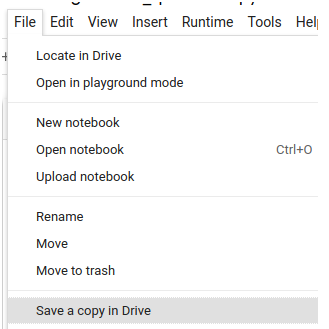

You will need to submit the EDITOR link of your notebook on Canvas (click share --> get link --> editor --> copy link).

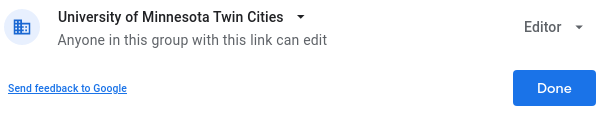


# Step 1 Setup

In [ ]:
!pip uninstall numpy -y
!pip install surprise
!pip install "numpy<2" --force-reinstall


## OK OK OK -- I hate this. It's going to make it say "Your session crashed for an unknown reason" because it force-restart the session, but after doing this every import seems to work just fine
import os
os.kill(os.getpid(), 9)


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 80.3 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505219 sha256=5d76d99e8c01835c0fc89be879c21e0d4939f96c11fd1e075da14fcf626cbd24
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 require

In [1]:
!# Feel free to add more imports here as needed

import random
import numpy as np
import pandas as pd
from surprise import AlgoBase, prediction_algorithms, Dataset, accuracy, Reader
from surprise.model_selection import KFold, GridSearchCV

from collections import defaultdict
from tqdm import tqdm

my_seed = 2025
random.seed(my_seed)
np.random.seed(my_seed)

In [2]:
# This cell help you get the dataframe movieId x tagId,
# Note -- this is by tag_id not raw tag name
# whose entries (i,j) represent the relevance between movie i and tag j.
url = 'https://drive.google.com/file/d/1eATlHqQKzAocs03Woxm4Bq8bJ-yeBLxa/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id=' + url.split('/')[-2]
movie_tags = pd.read_csv(path, index_col=0)
movie_tags.index = movie_tags.index.map(int).map(str) #the index of movie_tags has type str
display(movie_tags)

,15,46,60,89,125,149,151,188,205,230,...,901,937,949,951,952,956,1044,1063,1064,1067
movieId,,,,,,,,,,,,,,,,,,,,,
2,0.031,0.006,0.021,0.030,0.030,0.053,0.036,0.028,0.025,0.148,...,0.077,0.009,0.198,0.030,0.102,0.038,0.092,0.193,0.110,0.042
3,0.018,0.006,0.007,0.078,0.042,0.044,0.026,0.026,0.028,0.183,...,0.023,0.013,0.232,0.052,0.056,0.018,0.335,0.653,0.048,0.016
4,0.039,0.017,0.030,0.025,0.079,0.038,0.245,0.060,0.013,0.176,...,0.081,0.010,0.088,0.036,0.100,0.010,0.255,0.322,0.073,0.023
5,0.030,0.005,0.026,0.018,0.025,0.035,0.061,0.017,0.020,0.044,...,0.065,0.005,0.092,0.025,0.108,0.009,0.259,0.311,0.116,0.032
6,0.080,0.049,0.014,0.086,0.060,0.048,0.038,0.097,0.021,0.075,...,0.024,0.043,0.121,0.015,0.027,0.010,0.162,0.478,0.216,0.023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1664,0.031,0.006,0.013,0.033,0.038,0.025,0.030,0.025,0.023,0.289,...,0.037,0.009,0.118,0.062,0.047,0.017,0.069,0.224,0.102,0.046
1674,0.066,0.086,0.011,0.032,0.016,0.006,0.028,0.338,0.019,0.042,...,0.030,0.019,0.092,0.033,0.009,0.008,0.025,0.624,0.042,0.062
1675,0.147,0.016,0.007,0.598,0.018,0.032,0.025,0.046,0.023,0.034,...,0.026,0.008,0.190,0.017,0.309,0.027,0.204,0.145,0.137,0.005


In [3]:
# Download data and create trainset
data = Dataset.load_builtin('ml-100k')
trainset = data.build_full_trainset()

# Create rating dataframe and matrix
rating_df = pd.DataFrame([x for x in trainset.all_ratings()],
                            columns=["userId", "movieId", "ratings"])
rating_matrix = rating_df.pivot(index='userId', columns='movieId', values='ratings')
rating_matrix.fillna(0, inplace=True)
display(rating_matrix)

# Create full dataset, for predicting all ratings
fullset = trainset.build_testset() + trainset.build_anti_testset()

movieId,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
userId,,,,,,,,,,,,,,,,,,,,,
0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
939,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Step 2 Building a matrix factorization algorithm

We've implemented several algorithms already, but we've not done a gradient descent algorithm yet. As these are the most popular family right now -- I figured we should build one by hand to make sure we understand them!

For this step, you should implement the funk svd algorithm https://sifter.org/simon/journal/20061211.html (especially the part starting from "So, yeah, you mathy guys are rolling your eyes right now as it dawns on you how short the path was.")

For this coding task I'm having us directly code into the Surprise frameworks algorithm object, this will let you use the surprise framework training and tuning code if you wish.

The provided code has a few parameters set already:

* `n_epochs` how many times to loop over the entire training set of ratings when training a feature.
* `k` how many features to use
* `learning_rate` and `gamma` the standard gradient descent parameters $\alpha$ and $\lambda$ in the slides respectively.

Default values for these are set in the constructor, but you can easily override them.

Remember, the basic algorithm for funk's SVD has the following structure:

1. Initalize storage for all model parameters:
    * P (stores user features) a |U| x k matrix.
    * Q (stores item features) a |I| x k matrix.
    * Initalize these matrixes to zero.
2. For each feature f (1 .. k):
    1. Initalize the user and item feature f to random values.
    1. For each epoch (1 .. n_epoch):
        1. For each user, movie, rating pair with an observed rating
            1. Compute the prediction based on the current state of $P_u$ and $Q_i$.
            2. Compute the prediction error (rating - pred)
            3. Compute the updates to each feature (make sure these are computed _atomically_ -- I.E. don't use the updated userFeature when computing the update for the movieFeature.)
                * userFeature[user, f] += learning_rate * (error * movieFeature[f, movie] - gamma*userFeature[user, f]);
                * movieFeature[f, movie] += learning_rate * (error * userFeature[user, f] - gamma* movieFeature[f, movie]);

You will also need to make the prediction function which should:

1. Check if the user and item given are part of the training data
2. if not, return NaN or 0
3. if yes: return $P_u \cdot Q_i$

One final note. While I want you to take a stab at doing this without this, if you're getting super-stuck don't forget that I implemented a rather similar algorithm in-class: https://colab.research.google.com/drive/1t7cyBHYsxXOoeYeL7kpha2XMs6A6OMNS?usp=sharing

In [20]:
class BaselineBias(AlgoBase):
    def __init__(self, K, learningRate = 0.005, damping = 0.002, nEpoch = 40):
      AlgoBase.__init__(self)

      self.K = K
      self.learningRate = learningRate
      self.damping = damping
      self.nEpoch = nEpoch
      self.P = dict()#default to 0
      self.Q = dict()

    def fit(self, trainset):
      AlgoBase.fit(self, trainset)

      for item in self.trainset.all_items():
        self.Q[item] = [random.gauss() for i in range(self.K)]
      for user in self.trainset.all_users():
        self.P[user] = [random.gauss() for i in range(self.K)]


      for epoch in tqdm(range(self.nEpoch)):
            for user, item, rating in self.trainset.all_ratings():
              pred = 0
              for i in range(self.K):
                pred += self.P[user][i] * self.Q[item][i]
              err = rating - pred

              for i in range(self.K):
                temp = self.learningRate*(err*self.Q[item][i] - self.damping * self.P[user][i])
                self.Q[item][i] += self.learningRate*(err*self.P[user][i] - self.damping * self.Q[item][i])
                self.P[user][i] += temp

    def estimate(self, u, item):

        if u not in self.P or item not in self.Q:
          return 0

        pred = 0
        for i in range(self.K):
          pred += self.P[u][i] * self.Q[item][i]
        return pred

In [25]:
class MyFunkSVD(AlgoBase):
    def __init__(self, k=10, learningRate = 0.005, damping = 0.02, nEpoch = 20):
        AlgoBase.__init__(self)
        self.k=k
        self.learningRate = learningRate
        self.damping = damping
        self.nEpoch = nEpoch
        self.rating_df = None # this gets set in `fit`
        self.rating_matrix = None # this gets set in `fit`
        self.user_feature = dict()
        self.movie_feature = dict()

    def fit(self, trainset):
        # trainset: training dataset, https://surprise.readthedocs.io/en/stable/trainset.html?highlight=trainset
        AlgoBase.fit(self, trainset)

        self.rating_df = pd.DataFrame([x for x in trainset.all_ratings()],
                                   columns=["userId", "movieId", "ratings"])
        self.rating_matrix = self.rating_df.pivot(index='userId', columns='movieId', values='ratings')
        self.rating_matrix.index = self.rating_matrix.index.map(str)# get the list of userId (type str)
        self.rating_matrix.columns = self.rating_matrix.columns.map(str)# get the list of movieId (type str)
        self.predict_ratings = pd.DataFrame(index=self.rating_matrix.index, columns=self.rating_matrix.columns)

        ratings = self.rating_matrix.values
        n_users = ratings.shape[0]
        n_movies = ratings.shape[1]
        # here we initialize the P and Q matrixes (you can change the chosen names)
        # you will need to optimize the entries of these 2 matrices in your funksvd algorithm
        for item in trainset.all_items():
          self.movie_feature[item] = [random.gauss() for i in range(self.k)]
        for user in trainset.all_users():
          self.user_feature[user] = [random.gauss() for i in range(self.k)]

        for user, item, rating in trainset.all_ratings():
          for epoch in range(self.nEpoch):
            if rating > 0:
              pred = self.estimate(user, item)
              err = rating - pred

              for i in range(self.k):
                temp = self.learningRate*(err*self.movie_feature[item][i] - self.damping * self.user_feature[user][i])
                self.movie_feature[item][i] += self.learningRate*(err*self.user_feature[user][i] - self.damping * self.movie_feature[item][i])
                self.user_feature[user][i] += temp
        return self

    def estimate(self, user, item):
        # Prevent attempts to predict for users or items not in scope of ratings
        if user not in self.user_feature or item not in self.movie_feature:
            return 0

        # user_features = self.user_feature[user] I believe an indexing error prevented this from working properly
        # item_features = self.movie_feature[item]
        # prediction = np.dot(user_features, item_features)

        prediction = 0
        for i in range(self.k):
          prediction += self.user_feature[user][i] * self.movie_feature[item][i]


        return prediction


In [28]:
# Create a MyFunkSVD class object for predictions
my_funk_svd = MyFunkSVD()
my_funk_svd.fit(trainset)

predictions_fullset = my_funk_svd.test(fullset)
predictions_trainset = my_funk_svd.test(trainset.build_testset())
predictions_df = pd.DataFrame(predictions_fullset)
display(predictions_df)

,uid,iid,r_ui,est,details
0,196,242,3.00000,1.0,{'was_impossible': False}
1,196,393,4.00000,1.0,{'was_impossible': False}
2,196,381,4.00000,1.0,{'was_impossible': False}
3,196,251,3.00000,1.0,{'was_impossible': False}
4,196,655,5.00000,1.0,{'was_impossible': False}
...,...,...,...,...,...
1586121,941,1674,3.52986,1.0,{'was_impossible': False}
1586122,941,1640,3.52986,1.0,{'was_impossible': False}
1586123,941,1637,3.52986,1.0,{'was_impossible': False}
1586124,941,1630,3.52986,5.0,{'was_impossible': False}


# Step 3 building metrics

The surprise library has a scandalously small set of metrics built in. (In it's defense, it's not super-hard to use external metrics.) To help augment this we will be building two new metrics.*italicized text*

## Step 3.1 ILS@8

In this task, we will implement ILS based on tag genome (https://files.grouplens.org/datasets/tag-genome/README.html). The tag genome encodes how strongly movies exhibit particular properties represented by tags (atmospheric, thought-provoking, realistic, etc.). The tag genome was computed using a machine learning algorithm on user-contributed content including tags, ratings, and textual reviews.


Intra-list Similarity: ILS is a diversity metric. If you recommend a list L of recommendations ($item_1,...,item_n$) to a user, the ILS of this list is defined as $ILS(L) = \frac{1}{|L|\times(|L|-1)/2}\sum_{i\neq j, i,j\in L}Similarity(item_i,item_j)$. Here $Similarity(item_i,item_j)$ will be defined as the pearson correlation between $item_i$ and $item_j$'s representation in taggenome.

Your task is to calculate **ILS@8 (set k=8)** for each users' recommendation list, and **return the average ILS@8** across all users' recommendation lists.

In [29]:
# First, as a basic getting started, print the similarity (Pearson Correlation) between movieId 2 and id 3 according to movie_tags (which is created at step 1)
similarities = movie_tags.T.corr()
display(similarities.loc['2', '3'])

0.5434300977081341

In [30]:
# Calculates the ILS of a single user's recommendation list
def user_list_similarity(top_k_items):
  k = len(top_k_items) # |L|

  if k < 2:
    return 0

  denominator = (k*(k-1))/2
  item_similarities = []
  for i in range(k-1):
    item_i = top_k_items[i]
    for j in range(i+1, k):
      item_j = top_k_items[j]
      similarity = similarities.loc[str(item_i), str(item_j)]
      item_similarities.append(similarity)

  if denominator == 0:
    return 0

  return sum(item_similarities)/denominator

def intra_similarity(surprise_predictions, k_highest_scores=8):
    """
    Calculates the intra-similarity score from surprise predictions

    Parameters:
    surprise_predictions (List of surprise.prediction_algorithms.predictions.Prediction): list of predictions,
    see https://surprise.readthedocs.io/en/stable/predictions_module.html?highlight=prediction#surprise.prediction_algorithms.predictions.Prediction
    k_highest_scores (positive integer): Only consider the highest k scores (items) in each user's recommendation list.

    Returns:
    float in [-1, 1.]: The averaged ILS@5 over all users' recommendation lists.

    """
    uidset = list(set([p.uid for p in surprise_predictions]))
    iidset = list(set([p.iid for p in surprise_predictions]))
    ratings = pd.DataFrame(index=uidset, columns=iidset)
    for prediction in surprise_predictions:
      ratings.loc[prediction.uid, prediction.iid] = prediction.est
    ratings.fillna(0, inplace=True) # now we've transformed the predictions into a userId x movieId pred_rating dataframe

    # Creates a list of the top k items for each user
    top_k_items = np.argsort(ratings.values, axis=1)[:, -k_highest_scores:]

    # if a movie in the top k list is not in movie_tag's index, remove that movie from the top 5 list (but you don't need to add new movies to this top 5 list)
    # Then compute the ILS and return it.
    valid_top_k_items = []
    for user_top_k_items in top_k_items:
      valid_user_top_k_items = [item for item in user_top_k_items if str(item) in movie_tags.index]
      valid_top_k_items.append(valid_user_top_k_items)
    top_k_items = valid_top_k_items

    # Computes individual intra-list-similarities for each user
    user_similarities = []
    for index, user in enumerate(ratings.index):
      user_similarities.append(user_list_similarity(top_k_items[index]))

    # Returns the average of all user ILS values
    return sum(user_similarities)/len(user_similarities)

similarity = intra_similarity(predictions_fullset)
display(similarity)

0.540103361853139

## Step 3.2 NDCG

Let's implement the ndcg metric (Normalized Discounted Cumulative Gain). NDCG is the metric of measuring ranking quality. Fortunately, scikit learn (a dependency of surprise) has this built in! Unfortunately, it's input/output formats are not perfect. As a reminder, the basic metric:

* DCG accumulated at rank position k is given by
$DCG_p = \sum_{i=1}^k \frac {rel_i} {log_2 (i+1)} = rel_1 + \sum_{i=2}^k \frac {rel_i} {log_2 (i+1)}$.
Here $rel_i$ is relevance of the result at position i -- we could **use the true rating of the movie at position i as $rel_i$**, and **treat the unrated movies' true ratings as 0**.

* Normalized DCG (nDCG) is given by
$nDCG_k = \frac {DCG_k} {IDCG_k}$

  where
$IDCG_k = \sum_{i=1}^{|REL|} \frac {2^{rel_i} - 1} {log_2 (i+1)}$.  This is done by sorting all relevant documents in the corpus by their relative relevance, producing the maximum possible DCG through position
k -- called Ideal DCG (IDCG) at k.


In this task, you can use the ndcg_score of sklearn to calculate the score -- you need to figure out the correct input/output format, and **return the average ndcg@5** (**set k=5**) across all users' recommendation lists.

* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ndcg_score.html#sklearn.metrics.ndcg_score

In [31]:
from sklearn.metrics import ndcg_score
from scipy import sparse

def create_ndcg_matrices(predictions):
    preds = {}
    ratings = {}
    for prediction in predictions:
      userId = prediction.uid
      itemId = prediction.iid
      rating = prediction.r_ui
      pred = prediction.est
      if userId in preds:
        preds[userId][itemId] = pred
        ratings[userId][itemId] = rating
      else:
        preds[userId] = {itemId: pred}
        ratings[userId] = {itemId: rating}
    predictions_matrix = pd.DataFrame(preds).fillna(0)
    rating_matrix = pd.DataFrame(ratings).fillna(0)
    return predictions_matrix, rating_matrix


def ndcg(surprise_predictions, k=5):
    """
    Calculates the ndcg (normalized discounted cumulative gain) from surprise predictions, you could use sklearn.metrics.ndcg_score and scipy.sparse

    Parameters:
    surprise_predictions (List of surprise.prediction_algorithms.predictions.Prediction): list of predictions,
    see https://surprise.readthedocs.io/en/stable/predictions_module.html?highlight=prediction#surprise.prediction_algorithms.predictions.Prediction
    M: number of users
    N: number of movies
    k (positive integer): Only consider the highest k scores (items) in each user's recommendation list.

    Returns:
    float in [0., 1.]: The averaged NDCG scores over all users' recommendation lists.

    """
    # Task 3 to do start: return the ndcg score, with the help of sklearn ndcg_score package
    # hint: build 2 M x N matrices, each row representing the predicted/true ratings for one user -- and input that 2 matrices into ndcg_score directly.
    predictions_matrix, true_matrix = create_ndcg_matrices(surprise_predictions)
    score = ndcg_score(true_matrix, predictions_matrix, k=k)
    return score

    # Task 3 to do end

ndcg(predictions_trainset)

0.8245741735089702

# Step 4 Evaluation

OK, from here, we want you to perform a large algorithm-driven evaluation using the surprise toolkit.

* Datasets:
    * [https://surprise.readthedocs.io/en/stable/dataset.html](https://surprise.readthedocs.io/en/stable/dataset.html) We'll use ML100K and Jester -- both are "built-in".
    * ML100K -- the smallest and oldest of the movielens datasets.
    * Jester -- a joke recommendation project almost as old as the MovieLens project. Their datasets have some interesting properties. I should warn you these jokes were written over 20 years ago, not all of them aged well.
* Metrics:
    * ILS (as you implemented it above -- only use this for MovieLens)
    * NDCG (as you implemented it above)
    * RMSE (built-in: [https://surprise.readthedocs.io/en/stable/accuracy.html](https://surprise.readthedocs.io/en/stable/accuracy.html))
* Algorithms:
    * We will use the surprise algorithm implementations for _most_ of these.
    * bias(BaselineOnly),
    * UserUser(KNNBasic),
    * ItemItem(KNNBasic),  (KNNBasic, change sim_options to use UserUser or ItemItem)
    * NMF(NMF),
    * SVD (from Surpriese, set n_factors=10, n_epochs=20)
    * Your custom SVD from before.
* You should use 5-fold crossvalidation. You should be able to use the built-in code for this: <https://surprise.readthedocs.io/en/stable/getting_started.html#use-cross-validation-iterators> For consisitency set the random_state to 2025, that should help your results be comperable to that produced by others.

Your goal should be two "tables" -- one for ML100K, one for Jester, the rows of the tables would be each algorithm, the columns would be the different metrics.

## Step 4.1 Code the evaluation

In [32]:
# Code to load the Jester dataset and subsample it.

n_users = 5000 # subset to approximagely 10% of users, which is roughly 1/3rd of ratings.
# Load data into a pandas DataFrame first
jester = Dataset.load_builtin('jester')
jester_raw_ratings = pd.DataFrame(jester.raw_ratings, columns=['user', 'item', 'rating', 'timestamp'])
# display(raw_ratings)
# process jester
jester_rating_count_by_user = jester_raw_ratings.groupby("user")["rating"].count()
jester_rating_count_by_user = jester_rating_count_by_user.sort_values(ascending=False)
# display(jester_rating_count_by_user)
users = jester_rating_count_by_user.index[:n_users]
jester_ratings_df = jester_raw_ratings[jester_raw_ratings['user'].isin(users)][["user", "item", "rating"]]
jester_ratings_df[['item', 'rating']] = jester_ratings_df[['item', 'rating']].astype(int) + 10
# display(jester_ratings_df)
jester_subsample_dataset = Dataset.load_from_df(jester_ratings_df[["user", "item", "rating"]], jester.reader)
# display(jester_subample_dataset)

In [33]:
algorithms: list[AlgoBase] = {
    "Bias (Baseline Only)": prediction_algorithms.baseline_only.BaselineOnly(),
    "UserUser (KNNBasic)": prediction_algorithms.knns.KNNBasic(sim_options={"name": "pearson", "user_based": True}),
    "ItemItem (KNNBasic)": prediction_algorithms.knns.KNNBasic(sim_options={"name": "pearson", "user_based": False}),
    "NMF": prediction_algorithms.matrix_factorization.NMF(),
    "SVD (Surprise)": prediction_algorithms.matrix_factorization.SVD(),
    "Funk": MyFunkSVD()
}

metrics_jester = {
    "RMSE": accuracy.rmse,
    "NDCG@5": ndcg,
}

metrics_ml = metrics_jester.copy()
metrics_ml["ILS@8"] = intra_similarity

In [34]:
def get_results(dataset, algorithms, metrics):
  k = 5
  kf = KFold(n_splits=k, random_state=2025)
  results_df = pd.DataFrame(index=algorithms.keys(), columns=metrics.keys())

  for trainset, testset in tqdm(kf.split(dataset), desc="Evaluating Cross Folds", position=2, total=k):
    for algo_name, algorithm in tqdm(algorithms.items(), desc=f"Executing Algorithms", position=1):
      algorithm.fit(trainset)
      predictions = algorithm.test(trainset.build_testset())
      for metric_name, metric in metrics.items():
        results_df.loc[algo_name, metric_name] = results_df.loc[algo_name, metric_name] + metric(predictions) if pd.notna(results_df.loc[algo_name, metric_name]) else metric(predictions)

  return results_df / k

pd.set_option('future.no_silent_downcasting', True)

In [35]:
results_ml = get_results(data, algorithms, metrics_ml)
display(results_ml)



Executing Algorithms:   0%|          | 0/6 [00:00<?, ?it/s]

Estimating biases using als...
RMSE: 0.9227



Executing Algorithms:  17%|█▋        | 1/6 [00:06<00:33,  6.61s/it]

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 0.7545



Executing Algorithms:  33%|███▎      | 2/6 [00:24<00:53, 13.35s/it]

...

RMSE: 0.6878



Executing Algorithms:  83%|████████▎ | 5/6 [00:58<00:10, 10.98s/it]

RMSE: 1.2807



Executing Algorithms: 100%|██████████| 6/6 [01:16<00:00, 12.71s/it]


Evaluating Cross Folds: 100%|██████████| 5/5 [06:24<00:00, 76.95s/it]


,RMSE,NDCG@5,ILS@8
Bias (Baseline Only),0.92269,0.887754,0.524858
UserUser (KNNBasic),0.756001,0.981317,0.533434
ItemItem (KNNBasic),0.770345,0.97195,0.53544
NMF,0.796312,0.960153,0.530288
SVD (Surprise),0.685708,0.968408,0.53496
Funk,1.279942,0.833692,0.532396


In [36]:
results_jester = get_results(jester_subsample_dataset, algorithms, metrics_jester)
display(results_jester)



Executing Algorithms:   0%|          | 0/6 [00:00<?, ?it/s]

Estimating biases using als...
RMSE: 4.8966



Executing Algorithms:  17%|█▋        | 1/6 [00:05<00:28,  5.67s/it]

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 4.8073



Executing Algorithms:  33%|███▎      | 2/6 [32:03<1:15:22, 1130.60s/it]

...

RMSE: 4.2958



Executing Algorithms:  83%|████████▎ | 5/6 [35:49<04:32, 272.91s/it]

RMSE: 5.4485



Executing Algorithms: 100%|██████████| 6/6 [36:58<00:00, 369.74s/it]


Evaluating Cross Folds: 100%|██████████| 5/5 [3:02:40<00:00, 2192.15s/it]


,RMSE,NDCG@5
Bias (Baseline Only),4.897394,0.643719
UserUser (KNNBasic),4.805624,0.67251
ItemItem (KNNBasic),4.814174,0.652495
NMF,6.144669,0.917395
SVD (Surprise),4.296617,0.718241
Funk,5.439662,0.637853


In [ ]:
display(results_ml)
display(results_jester)

## Step 4.2 Analyze the results
In the text-cell below answer the following questions, don't forget to explain your reasoning (aim for around 2 sentences per question)

1) Based on the results above, Identify the algorithm that you feel could be best for https://movielens.org/ on the top picks page.

I would think that for the top picks page, we would care most about the results being accurate, novel, and impacting the user's behavior. Based on the results, I would think that the Surprise SVD algorithm offers the highest accuracy, high NDCG, and ILS that is not meaningfully different from the others. Therefore it seems to be the most effective for this use case.

2) Based on the results above, Identify the algorithm that you feel could be best for MovieLens on the rate more page.

For the rate more page, our goal is to refine our profile of the user by offering items to them that provide us with the most information about their profile. Therefore, diversity is certainly important so as to get a full range of understanding. Despite having poor accuracy and gain, the Baseline algorithm is the most likely to provide the user with diverse choices that aren't biased towards their pre-existing patterns.

3) Based on the results above, Identify the algorithm that you feel could be best for the Jester website.

I would ultimately decide upon the NMF algorithm. While it does have the (significantly) worst RMSE score observed, it also has a NDCG score that is much higher than the rest. While SVD or UserUser have high RMSE scores, their low NDCG scores suggest that they are less likely to make meaningful suggestions to the user.

# Step 5 Tuning an algorithm for a specific domain

While manual evaluations like you've seen above are a common way to perform parameter tuning, many software libraries contain "All in one" functions that will automatically search a range of parameter settings and report the best value. The code for surprise is outlined here: https://surprise.readthedocs.io/en/stable/getting_started.html#tune-algorithm-parameters-with-gridsearchcv

Use this to find the _best_ version of Item-Item, and SVD algorithms you can for the ML100K dataset.

## Step 5.1 Tuning

Make sure you include both CODE to do the tuning, and something to output your final tuning here.

* Optimize for RMSE
* For Item-Item, at a minimum you should compare different similarity metrics, and a range of $k$ values (at least 5 different values)
* For SVD (Suprise version), at a minimum try 5 or 10 epochs, 0.002 or 0.005 learning rate, and 0.4 or 0.6 regularization. (Note -- this is 100% the exact optimization problem you can find in the getting stated notes -- this is not a mistake, enjoy!)

For both you are encouraged to go far above and beyond the minimums here, tuning is not something you can ever really be "done" with -- you just gotta get the best you can and decide that chasing another 0.01RMSE is not worth it.
Likewise, you are encouraged to compete with others on slack to see who can find the best RMSE.

In [38]:
param_grid_ii = {
    "k": [10, 20, 40, 80, 160],
    "sim_options": {
        "name": ["cosine", "pearson", "msd"],
        "user_based": [False]
    }
}

param_grid_svd = {
    "n_epochs": [5, 10, 15],
    "lr_all": [0.002, 0.005, 0.05, 0.5],
    "reg_all": [0.4, 0.6, 0.8],
}

gs_ii = GridSearchCV(prediction_algorithms.knns.KNNBasic, param_grid_ii, measures=["rmse"], cv=5)
gs_svd = GridSearchCV(prediction_algorithms.matrix_factorization.SVD, param_grid_svd, measures=["rmse"], cv=5)

In [39]:
gs_ii.fit(data)
gs_svd.fit(data)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the ms

In [42]:
print("\nBest RMSE Scores:")
print(f"Item-Based CF RMSE: {gs_ii.best_score['rmse']:.4f}")
print(f"SVD RMSE: {gs_svd.best_score['rmse']:.4f}")
print("\nBest Parameters:")
print(f"Item-Based CF Parameters: {gs_ii.best_params}")
print(f"SVD Parameters: {gs_svd.best_params}")


Best RMSE Scores:
Item-Based CF RMSE: 0.9747
SVD RMSE: 0.9586

Best Parameters:
Item-Based CF Parameters: {'rmse': {'k': 40, 'sim_options': {'name': 'msd', 'user_based': False}}}
SVD Parameters: {'rmse': {'n_epochs': 15, 'lr_all': 0.005, 'reg_all': 0.4}}


In [41]:
display(results_ml)

,RMSE,NDCG@5,ILS@8
Bias (Baseline Only),0.92269,0.887754,0.524858
UserUser (KNNBasic),0.756001,0.981317,0.533434
ItemItem (KNNBasic),0.770345,0.97195,0.53544
NMF,0.796312,0.960153,0.530288
SVD (Surprise),0.685708,0.968408,0.53496
Funk,1.279942,0.833692,0.532396


## Step 5.2 reflection

One final question: How much better, or worse, does the optimized algorithms perform than the prior versions?

Answer here:

It appears as though both the itemitem and svd algorithms perform worse here than they did prior. The optimized version of item-item produced an RMSE score of 0.9739 while the prior version produced 0.7703, the svd algorithm producing 0.9584 and 0.6871 respectively. These differences are significant and unintuitive, and I am unsure of what would cause this discrepancy. By all means, I would expect the optimized RMSE score for both algorithms to drop significantly.